In [1]:
# Cell 1 — Imports
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

# Dataset path
DATASET_PATH = Path("/home/soban_ali_awan/aerosonic/data/raw/DroneAudioDataset/Binary_Drone_Audio")
DRONE_PATH = DATASET_PATH / "yes_drone"
UNKNOWN_PATH = DATASET_PATH / "unknown"

# Count files
drone_files = list(DRONE_PATH.glob("*.wav"))
unknown_files = list(UNKNOWN_PATH.glob("*.wav"))

print(f"✅ Drone files:   {len(drone_files)}")
print(f"✅ Unknown files: {len(unknown_files)}")
print(f"✅ Total files:   {len(drone_files) + len(unknown_files)}")
print(f"\n📁 Sample drone file: {drone_files[0].name}")
print(f"📁 Sample unknown file: {unknown_files[0].name}")

✅ Drone files:   1332
✅ Unknown files: 10372
✅ Total files:   11704

📁 Sample drone file: extra_membo_D2_2018.wav
📁 Sample unknown file: 1-37226-A-290.wav


📁 File: extra_membo_D2_2018.wav
⏱️  Duration: 1.00 seconds
🎵 Sample rate: 16000 Hz
📊 Total samples: 16043
📈 Min amplitude: -0.0294
📈 Max amplitude: 0.0366


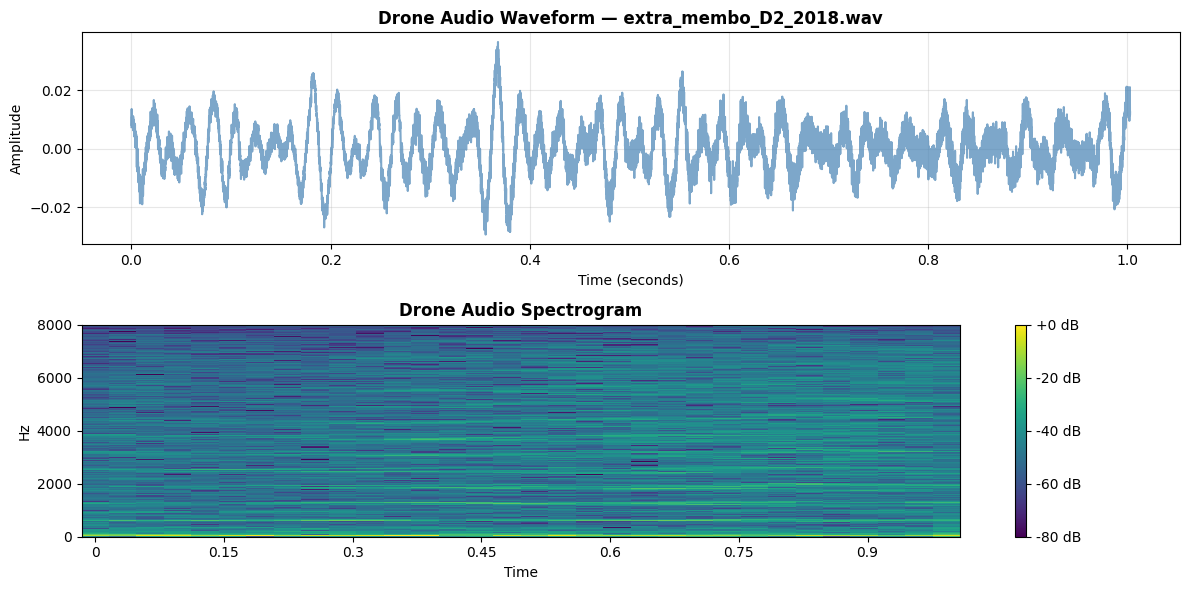

✅ Figure saved!


In [3]:
# Cell 2 — Load and visualize one drone audio file
# Pehli drone file load karo
drone_file = drone_files[0]
audio, sr = librosa.load(drone_file, sr=16000)

print(f"📁 File: {drone_file.name}")
print(f"⏱️  Duration: {len(audio)/sr:.2f} seconds")
print(f"🎵 Sample rate: {sr} Hz")
print(f"📊 Total samples: {len(audio)}")
print(f"📈 Min amplitude: {audio.min():.4f}")
print(f"📈 Max amplitude: {audio.max():.4f}")

# Plot karo
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Waveform
axes[0].plot(np.linspace(0, len(audio)/sr, len(audio)), audio, 
             color='steelblue', alpha=0.7)
axes[0].set_title(f'Drone Audio Waveform — {drone_file.name}', 
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

# Spectrogram
D = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)
librosa.display.specshow(D, sr=sr, x_axis='time', 
                          y_axis='hz', ax=axes[1], cmap='viridis')
axes[1].set_title('Drone Audio Spectrogram', 
                   fontsize=12, fontweight='bold')
plt.colorbar(axes[1].collections[0], ax=axes[1], 
             format='%+2.0f dB')

plt.tight_layout()
plt.savefig('/home/soban_ali_awan/aerosonic/results/figures/drone_waveform.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure saved!")

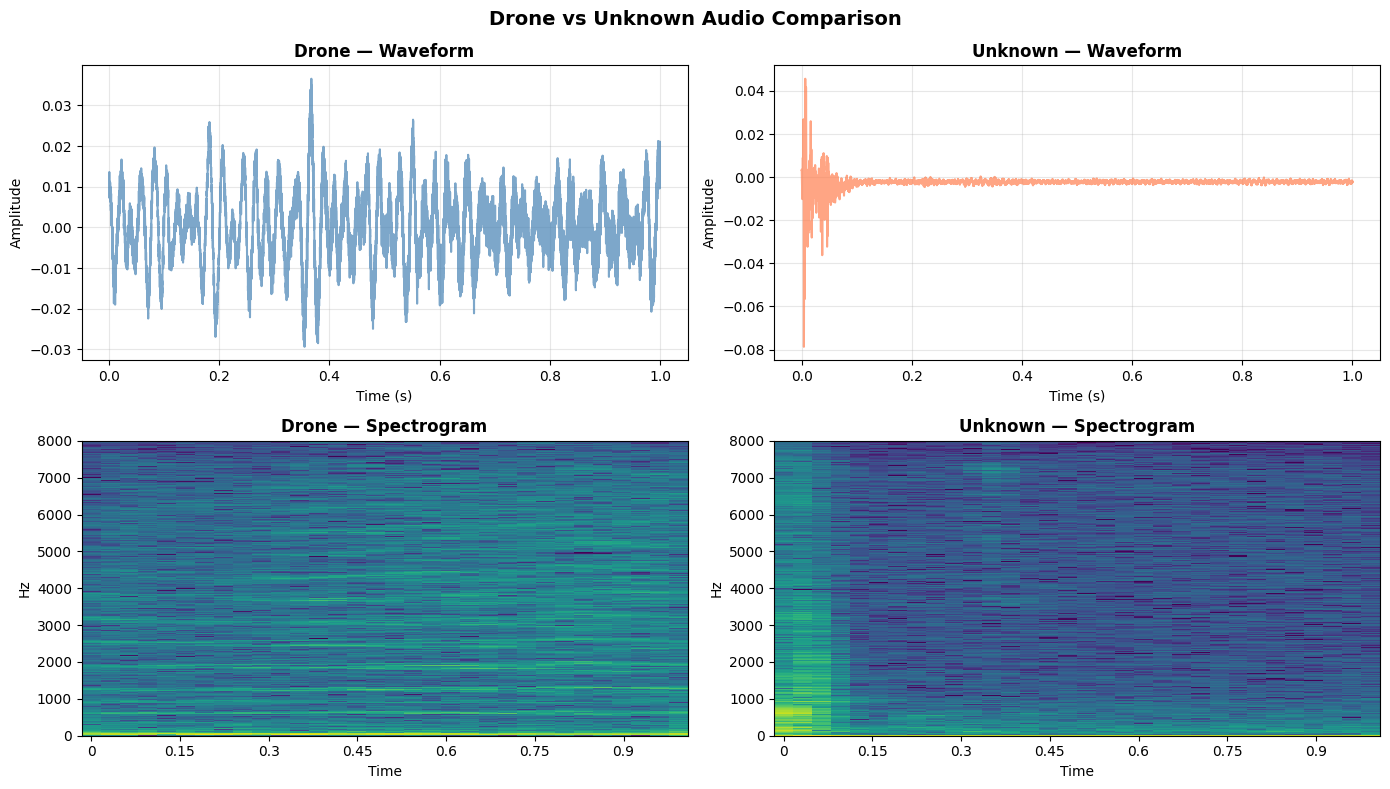

✅ Comparison figure saved!


In [4]:
# Cell 3 — Compare drone vs unknown
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Drone audio
drone_audio, sr = librosa.load(drone_files[0], sr=16000)
# Unknown audio
unknown_audio, sr = librosa.load(unknown_files[0], sr=16000)

# Drone waveform
axes[0,0].plot(np.linspace(0, 1, len(drone_audio)), 
               drone_audio, color='steelblue', alpha=0.7)
axes[0,0].set_title('Drone — Waveform', fontweight='bold')
axes[0,0].set_xlabel('Time (s)')
axes[0,0].set_ylabel('Amplitude')
axes[0,0].grid(True, alpha=0.3)

# Unknown waveform
axes[0,1].plot(np.linspace(0, 1, len(unknown_audio)), 
               unknown_audio, color='coral', alpha=0.7)
axes[0,1].set_title('Unknown — Waveform', fontweight='bold')
axes[0,1].set_xlabel('Time (s)')
axes[0,1].set_ylabel('Amplitude')
axes[0,1].grid(True, alpha=0.3)

# Drone spectrogram
D_drone = librosa.amplitude_to_db(
    np.abs(librosa.stft(drone_audio)), ref=np.max)
librosa.display.specshow(D_drone, sr=sr, x_axis='time',
                          y_axis='hz', ax=axes[1,0], 
                          cmap='viridis')
axes[1,0].set_title('Drone — Spectrogram', fontweight='bold')

# Unknown spectrogram
D_unknown = librosa.amplitude_to_db(
    np.abs(librosa.stft(unknown_audio)), ref=np.max)
librosa.display.specshow(D_unknown, sr=sr, x_axis='time',
                          y_axis='hz', ax=axes[1,1], 
                          cmap='viridis')
axes[1,1].set_title('Unknown — Spectrogram', fontweight='bold')

plt.suptitle('Drone vs Unknown Audio Comparison', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/soban_ali_awan/aerosonic/results/figures/comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparison figure saved!")

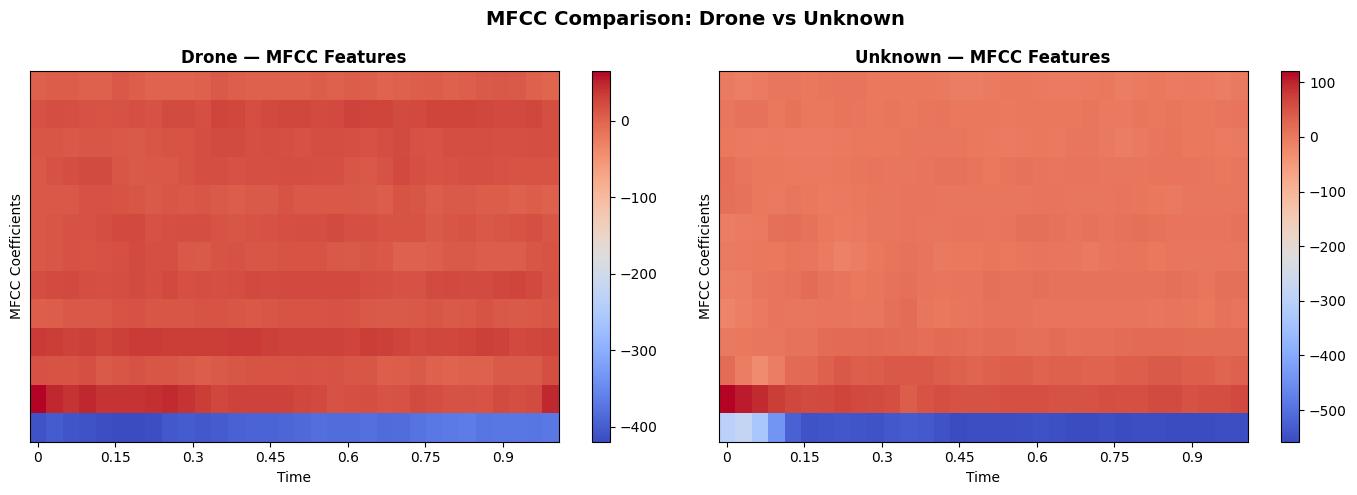

✅ Drone MFCC shape: (13, 32)
✅ Unknown MFCC shape: (13, 32)

📊 Drone MFCC mean values:
[-390.57   29.83   10.71   30.02   11.43   20.99   11.72   15.96    9.7
   16.06   16.73   22.35    4.27]

📊 Unknown MFCC mean values:
[-5.2268e+02  6.1900e+01  3.0780e+01  1.5890e+01  6.0200e+00  8.6200e+00
  3.2900e+00  6.9500e+00  4.7400e+00  5.7300e+00  1.2000e+00  3.8600e+00
 -6.0000e-02]


In [5]:
# Cell 4 — MFCC Feature Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Drone MFCC
mfcc_drone = librosa.feature.mfcc(
    y=drone_audio, sr=sr, n_mfcc=13)
librosa.display.specshow(mfcc_drone, sr=sr, 
                          x_axis='time', ax=axes[0],
                          cmap='coolwarm')
axes[0].set_title('Drone — MFCC Features', 
                   fontweight='bold', fontsize=12)
axes[0].set_ylabel('MFCC Coefficients')
plt.colorbar(axes[0].collections[0], ax=axes[0])

# Unknown MFCC
mfcc_unknown = librosa.feature.mfcc(
    y=unknown_audio, sr=sr, n_mfcc=13)
librosa.display.specshow(mfcc_unknown, sr=sr,
                          x_axis='time', ax=axes[1],
                          cmap='coolwarm')
axes[1].set_title('Unknown — MFCC Features',
                   fontweight='bold', fontsize=12)
axes[1].set_ylabel('MFCC Coefficients')
plt.colorbar(axes[1].collections[0], ax=axes[1])

plt.suptitle('MFCC Comparison: Drone vs Unknown',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/soban_ali_awan/aerosonic/results/figures/mfcc_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

# MFCC values print karo
print(f"✅ Drone MFCC shape: {mfcc_drone.shape}")
print(f"✅ Unknown MFCC shape: {mfcc_unknown.shape}")
print(f"\n📊 Drone MFCC mean values:")
print(np.mean(mfcc_drone, axis=1).round(2))
print(f"\n📊 Unknown MFCC mean values:")
print(np.mean(mfcc_unknown, axis=1).round(2))